In [1]:
# import modules
import numpy as np
import random
import math
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.ticker as tick #Importing tick function
from tqdm import tqdm
from time import time
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors 

np.set_printoptions(suppress=True)

2024-04-22 14:50:04.055294: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-22 14:50:04.055353: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-22 14:50:04.055374: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-22 14:50:04.061948: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
plt.style.use('ggplot')
plt.style.use('seaborn-v0_8-whitegrid')
plt.style.use('seaborn-v0_8-paper')

In [3]:
# Load data
cov_cubeT = np.load("../data/cov_N_10000_b1_0.1_repeat_0.npy") # Ten thousand
cov_cubeHT = np.load("../data/cov_N_100000_b1_0.1_repeat_0.npy")# Hundred thousand
cov_cubeM = np.load("../data/cov_N_1000000_b1_0.1_repeat_0.npy")# 1 Million

# Load data
dat=pd.read_csv("../synthetic_inference/model_fit_sine_wave.csv")

# Add column names
dat.columns=["nbObs","truebeta1","repeat","betamean1",
        "betastd1","z1","z2"]

In [4]:
dat.head()

,nbObs,truebeta1,repeat,betamean1,betastd1,z1,z2
0,10001,0.1,0,0.046957,0.118942,0.445954,NaN
1,100001,0.1,0,0.104409,0.041415,-0.106462,NaN
2,1000001,0.1,0,0.098724,0.018734,0.068111,NaN
3,10001,0.1,1,0.133993,0.121655,-0.279421,NaN
4,100001,0.1,1,0.116242,0.041112,-0.395078,NaN


In [5]:
# True utilisation distribution
Trueb1=dat.truebeta1.iloc[0]

# 10000 observations
UDT=np.exp(Trueb1*cov_cubeT[0])
UDT=np.divide(UDT,np.sum(UDT))

# 100000 observations
UDHT=np.exp(Trueb1*cov_cubeHT[0])
UDHT=np.divide(UDHT,np.sum(UDHT))

# 1000000 observations
UDM=np.exp(Trueb1*cov_cubeM[0])
UDM=np.divide(UDM,np.sum(UDM))

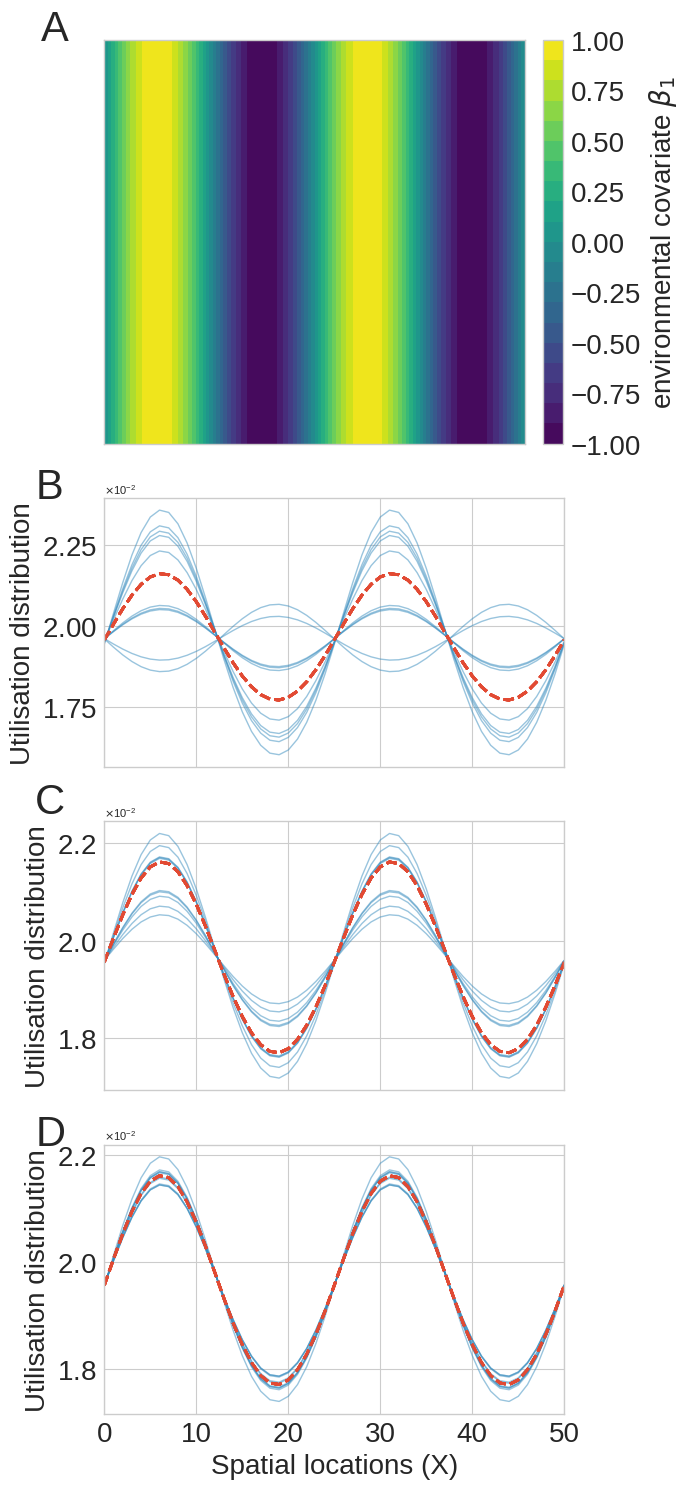

In [10]:
# Plotting 4 by 1
formatter = tick.ScalarFormatter(useMathText=True)
formatter.set_scientific(True) 
formatter.set_powerlimits((-1,1)) 

# Recovered values
kT=dat.loc[dat.nbObs==10001,"betamean1"].values
kHT=dat.loc[dat.nbObs==100001,"betamean1"].values
kM=dat.loc[dat.nbObs==1000001,"betamean1"].values

fig,axs = plt.subplots(4,1,figsize=(7,15),gridspec_kw={'height_ratios': [1.5, 1, 1, 1]})

# Environmental covariate
ax0=axs[0].contourf(cov_cubeT[0],cmap='viridis',levels=20)
#axs[0,0].set_aspect('equal')
axs[0].text(-0.15,1,'A', size=30, transform=axs[0].transAxes)
axs[0].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax0, ax=axs[0],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.set_label(label=r'environmental covariate $\beta_1$',size=20)
tick_locator = tick.MaxNLocator(nbins=8)
cbar.locator = tick_locator

# Utilisation distribution for 10000 observations
for i in kT:
    UDS1=np.exp(i*cov_cubeT[0])
    UDS1=np.divide(UDS1,np.sum(UDS1))
    axs[1].plot(np.sum(UDS1,axis=0), color="C1",linewidth=1.0,alpha=0.5)
    axs[1].plot(np.sum(UDT,axis=0),color="C0", linewidth=2,ls="--")
#axs[1].set_xlabel("Spatial locations (X)",fontsize=20)
axs[1].set_ylabel("Utilisation distribution",fontsize=20)
axs[1].set_xlim(0,50)
axs[1].yaxis.set_major_formatter(formatter)
axs[1].tick_params(axis='both', which='major', labelsize=20,labelbottom=False)
axs[1].text(-0.15,1,'B', size=30, transform=axs[1].transAxes)

# Utilisation distribution for 100000 observations
for i in kHT:
    UDS1=np.exp(i*cov_cubeT[0])
    UDS1=np.divide(UDS1,np.sum(UDS1))
    axs[2].plot(np.sum(UDS1,axis=0), color="C1",linewidth=1.0,alpha=0.5)
    axs[2].plot(np.sum(UDHT,axis=0),color="C0", linewidth=2,ls="--")
#axs[2].set_xlabel("Spatial locations (X)",fontsize=20)
axs[2].set_ylabel("Utilisation distribution",fontsize=20)
axs[2].yaxis.set_major_formatter(formatter)
axs[2].set_xlim(0,50)
axs[2].tick_params(axis='both', which='major', labelsize=20,labelbottom=False)
axs[2].text(-0.15,1.03,'C', size=30, transform=axs[2].transAxes)

# Utilisation distribution for 1000000 observations
for i in kM:
    UDS1=np.exp(i*cov_cubeM[0])
    UDS1=np.divide(UDS1,np.sum(UDS1))
    axs[3].plot(np.sum(UDS1,axis=0), color="C1",linewidth=1.0,alpha=0.5)
    axs[3].plot(np.sum(UDM,axis=0),color="C0", linewidth=2,ls="--")
axs[3].set_xlabel("Spatial locations (X)",fontsize=20)
axs[3].set_ylabel("Utilisation distribution",fontsize=20)
axs[3].yaxis.set_major_formatter(formatter)
axs[3].set_xlim(0,50)
axs[3].tick_params(axis='both', which='major', labelsize=20)
axs[3].text(-0.15,1,'D', size=30, transform=axs[3].transAxes)

fig.subplots_adjust(left=0.02,bottom=0.01,right=0.07, 
                    top=0.9, wspace=0.0001, hspace=0.1)
plt.tight_layout()
plt.savefig("Figure_4.png",bbox_inches='tight',dpi=300)
plt.show()

In [28]:
############################ Utilisation distribution  ##########################################

# Covariates
cov1=cov_cube[0]
cov2=cov_cube[1]


# Parameters from the posterior distributions 
b1mean = dat.betamean1.iloc[8] # Mean for cov 1
b1scale = dat.betastd1.iloc[8] # Standard deviation for cov 1
b2mean = dat.betamean2.iloc[8] # Mean for cov 2
b2scale = dat.betastd2.iloc[8] # Standard deviation for cov 2


################## Credible interval #############################################################
# For Covariates 1
Lci1=b1mean-1.96*b1scale
Uci1=b1mean + 1.96*b1scale

# For Covariates 2
Uci2=b2mean-1.96*b2scale
Lci2=b2mean + 1.96*b2scale

################## Utilization distribution #########################################################
cov1=cov_cube[0]
# Lower credible interval
UDL=np.exp(Lci1*cov1+ Lci2*cov2 )
UDL=np.divide(UDL,np.sum(UDL))

UDU=np.exp(Uci1*cov1 + Uci2*cov2)
UDU=np.divide(UDU,np.sum(UDU))

# Mean utilisation distribution
UDM=np.exp(b1mean*cov1 + b2mean*cov2)
UDM=np.divide(UDM,np.sum(UDM))

/tmp/ipykernel_160/2804185657.py:91: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.02,bottom=0.1,right=0.07,


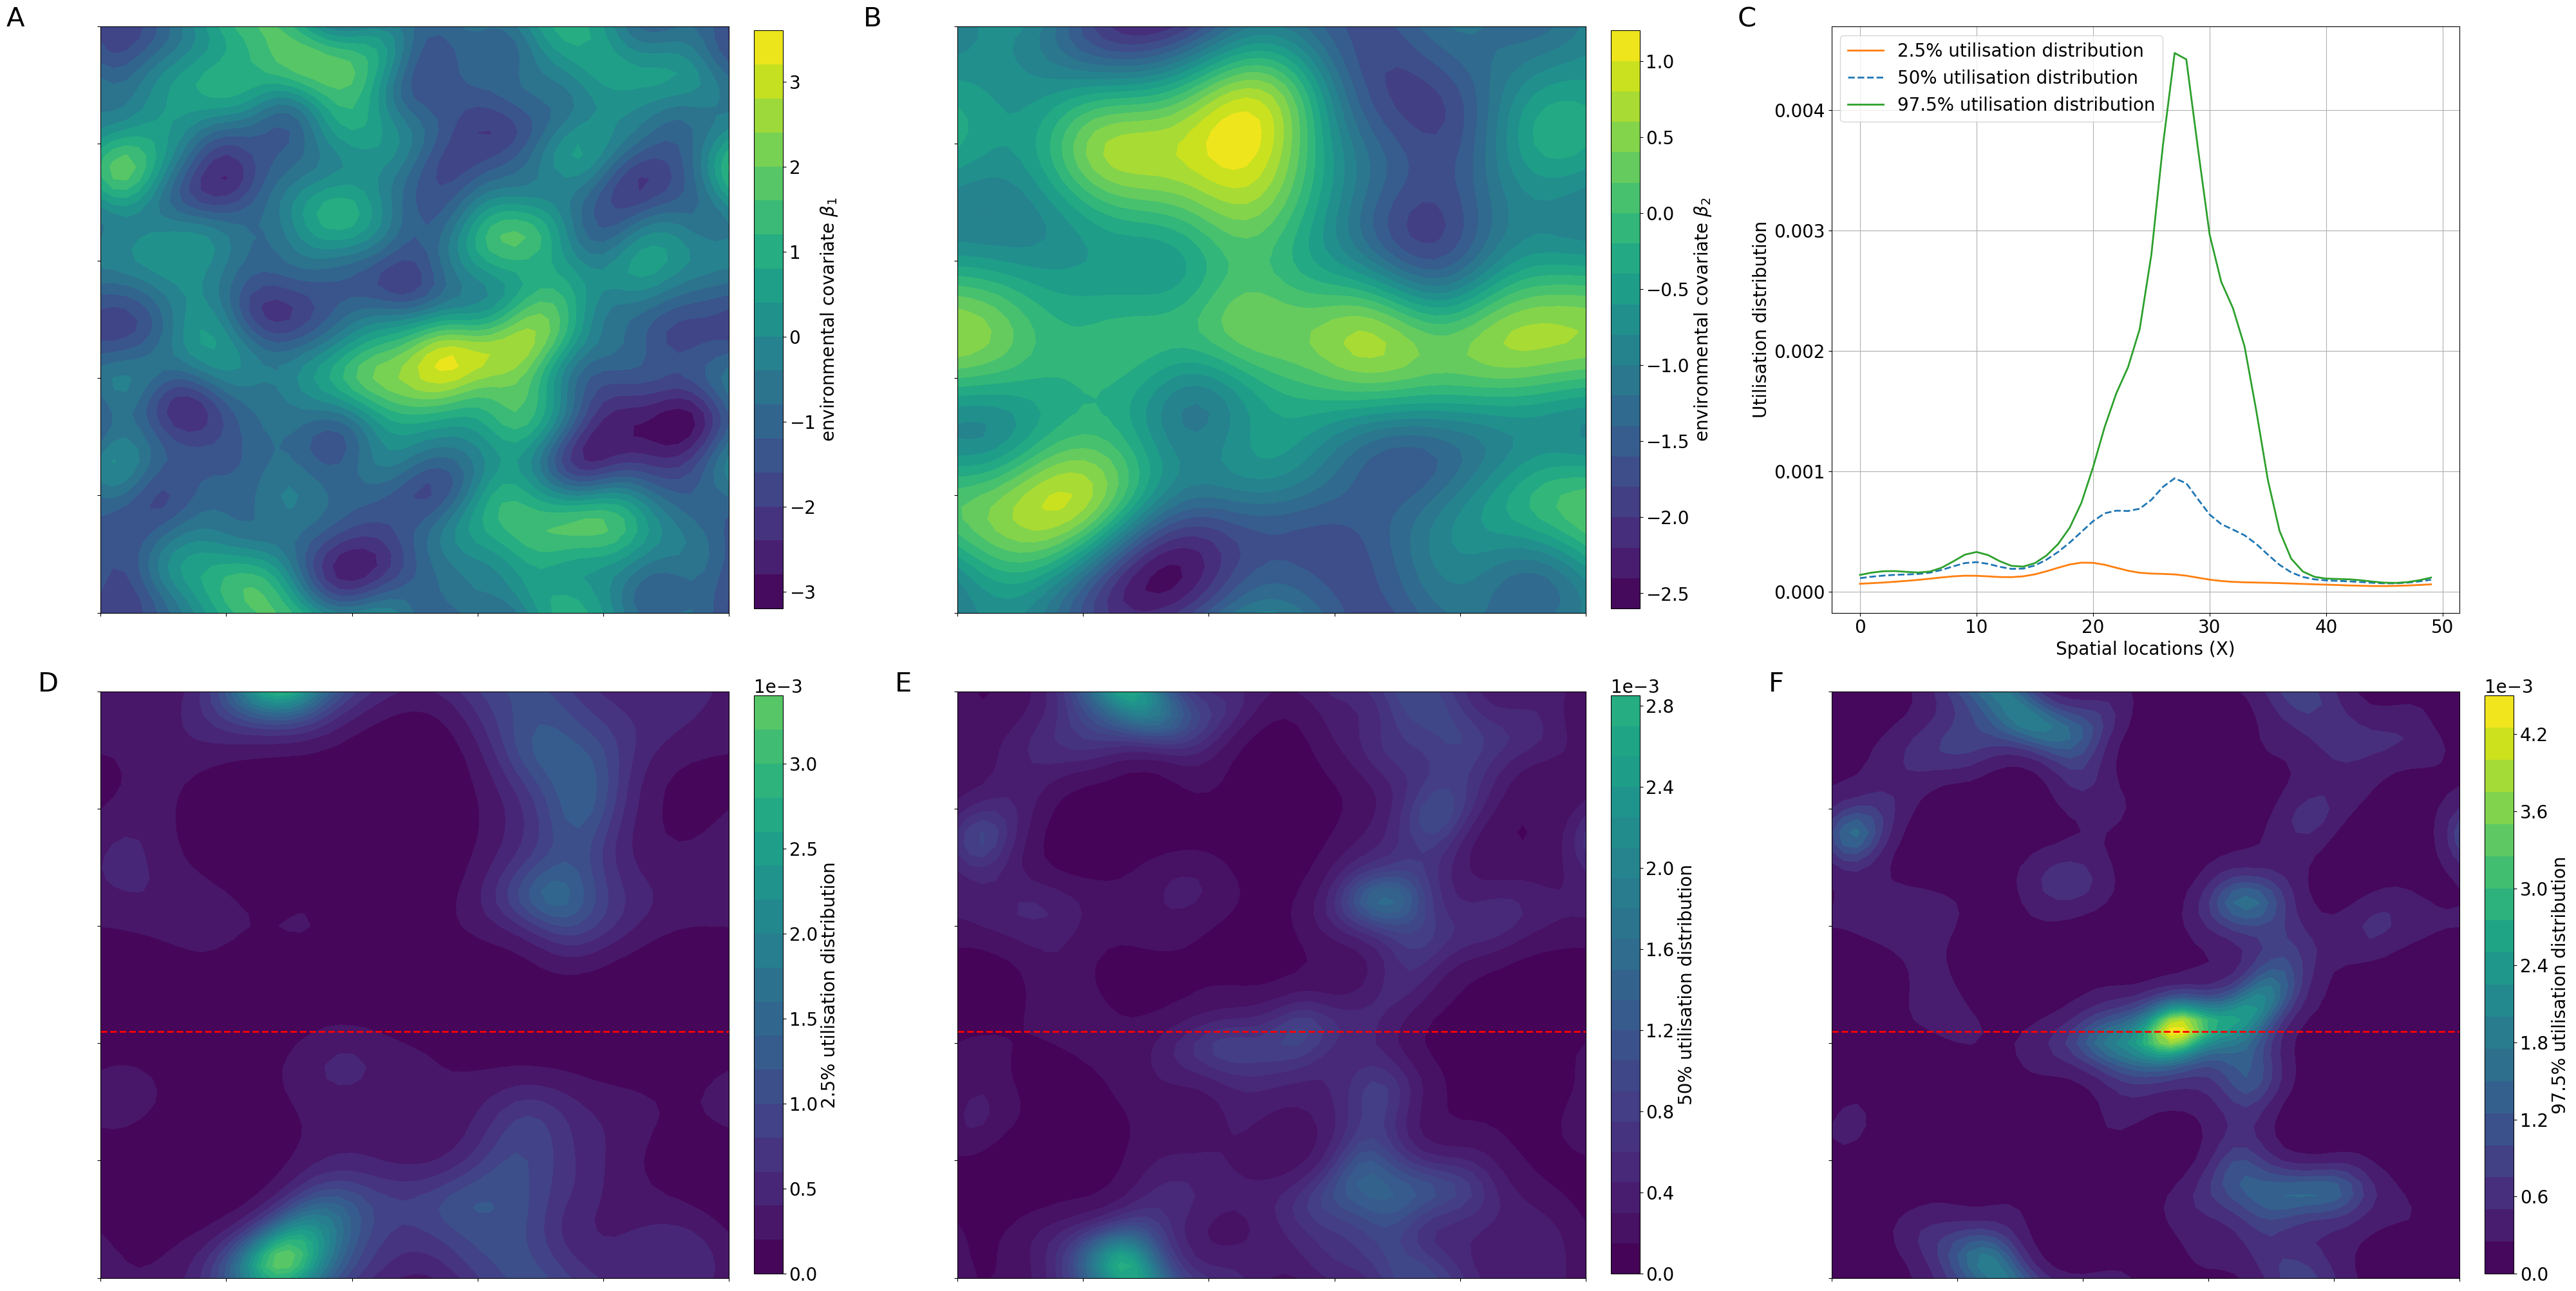

In [49]:

## Plotting 2 by 2 for utilisation distribution, environment covariates 1 and
## line graph on the same panel

fig, axs = plt.subplots(2, 3, figsize=(40,20),constrained_layout=True)
ax0=axs[0,0].contourf(cov1,cmap='viridis',levels=20)
#axs[0,0].set_aspect('equal')
axs[0,0].text(-0.15,1,'A', size=30, transform=axs[0,0].transAxes)
axs[0,0].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax0, ax=axs[0,0],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.set_label(label=r'environmental covariate $\beta_1$',size=20)
tick_locator = tick.MaxNLocator(nbins=8)
cbar.locator = tick_locator
cbar.update_ticks()

ax1=axs[0,1].contourf(cov2,cmap='viridis',levels=20)
#axs[0,1].set_aspect('equal')
axs[0,1].text(-0.15,1,'B', size=30, transform=axs[0,1].transAxes)
axs[0,1].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax1, ax=axs[0,1],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.set_label(label=r'environmental covariate $\beta_2$',size=20)
tick_locator = tick.MaxNLocator(nbins=8)
cbar.locator = tick_locator
cbar.update_ticks()


axs[0,2].plot(UDL[21,0:50], color="C1",linewidth=2.0,label=r'2.5% utilisation distribution')
axs[0,2].plot(UDM[21,0:50],color="C0", linewidth=2.0,ls="--",label=r'50% utilisation distribution')
axs[0,2].plot(UDU[21,0:50],color="C2", linewidth=2.0,label=r'97.5% utilisation distribution')
axs[0,2].set_xlabel("Spatial locations (X)",fontsize=20)
axs[0,2].set_ylabel("Utilisation distribution",fontsize=20)
axs[0,2].tick_params(axis='both', which='major', labelsize=20)
axs[0,2].text(-0.15,1,'C', size=30, transform=axs[0,2].transAxes)
axs[0,2].grid(True)
axs[0,2].legend(loc="best",fontsize=20)

ax2= axs[1, 0].contourf(UDL,cmap='viridis',levels=20,vmin=UDU.min(),vmax=UDU.max())
#axs[1,0].set_aspect('equal')
axs[1,0].text(-0.1,1,'D', size=30, transform=axs[1,0].transAxes)
axs[1,0].tick_params( labelleft=False, labelbottom=False) 
axs[1,0].axhline(21,color="red",ls="--",linewidth=2)
cbar = fig.colorbar(ax2, ax=axs[1,0],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left') 
cbar.set_label(label=r'2.5% utilisation distribution',size=20)
tick_locator = tick.MaxNLocator(nbins=8)
cbar.locator = tick_locator
cbar.update_ticks()

ax3= axs[1, 1].contourf(UDM,cmap='viridis',levels=20,vmin=UDU.min(),vmax=UDU.max())
#axs[1,1].set_aspect('equal')
axs[1,1].text(-0.1,1,'E', size=30, transform=axs[1,1].transAxes)
axs[1,1].tick_params( labelleft=False, labelbottom=False) 
axs[1,1].axhline(21,color="red",ls="--",linewidth=2)
cbar = fig.colorbar(ax3, ax=axs[1,1],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left') 
cbar.set_label(label=r'50% utilisation distribution',size=20)
tick_locator = tick.MaxNLocator(nbins=8)
cbar.locator = tick_locator
cbar.update_ticks()

ax4 = axs[1,2].contourf(UDU,cmap='viridis',levels=20,vmin=UDU.min(),vmax=UDU.max())
#axs[1,2].set_aspect('equal')
axs[1,2].text(-0.1,1,'F', size=30, transform=axs[1,2].transAxes)
axs[1,2].axhline(21,color="red",ls="--",linewidth=2)
axs[1,2].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax4, ax=axs[1,2],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.ax.tick_params(labelsize=20) 
cbar.set_label(label=r'97.5% utilisation distribution',size=20)
tick_locator = tick.MaxNLocator(nbins=8)
cbar.locator = tick_locator
cbar.update_ticks()


fig.subplots_adjust(left=0.02,bottom=0.1,right=0.07, 
                    top=0.9, wspace=0.0001, hspace=0.1)

plt.savefig("Figure_4.png",bbox_inches='tight',dpi=300)
plt.show()

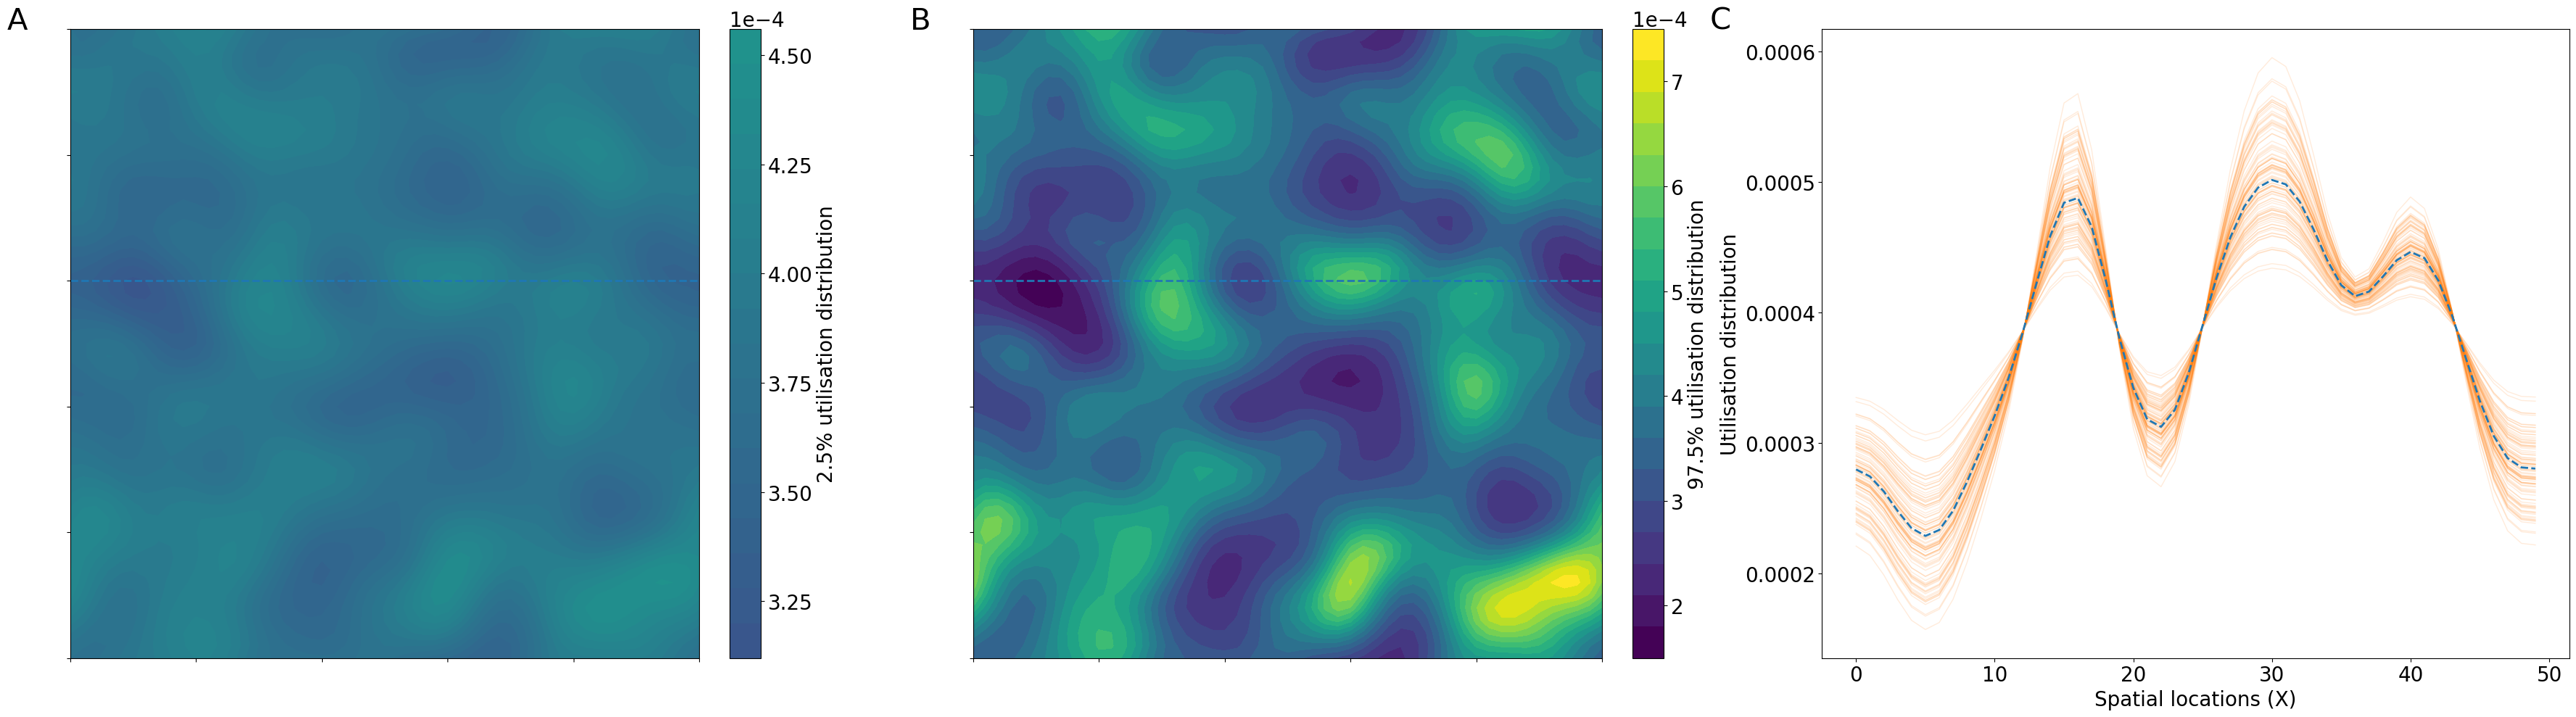

In [26]:

## Plotting 2 by 2 for utilisation distribution, environment covariates 1 and
## line graph on the same panel

import matplotlib.ticker as tick #Importing tick function

fig, axs = plt.subplots(1, 3, figsize=(36,10),tight_layout=True)

# Figure A
# Setting aspect ratio 
axs[0].set_aspect('equal')
ax0= axs[0].contourf(UDL,cmap='viridis',levels=20,vmin=UDU.min(),vmax=UDU.max())#,vmin=UDU.min(),vmax=UDU.max())
axs[0].text(-0.1,1,'A', size=30, transform=axs[0].transAxes)
axs[0].tick_params( labelleft=False, labelbottom=False) 
axs[0].axhline(30,color="C0",ls="--",linewidth=2)
cbar = fig.colorbar(ax0, ax=axs[0],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left') 
cbar.set_label(label=r'2.5% utilisation distribution',size=20)
tick_locator = tick.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()

# Figure B
axs[1].set_aspect('equal')
ax11 = axs[1].contourf(UDU,cmap='viridis',levels=20,vmin=UDU.min(),vmax=UDU.max())#vmin=UDU.min(),vmax=UDU.max())
axs[1].text(-0.1,1,'B', size=30, transform=axs[1].transAxes)
axs[1].axhline(30,color="C0",ls="--",linewidth=2)
axs[1].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax11, ax=axs[1],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.ax.tick_params(labelsize=20) 
cbar.set_label(label=r'97.5% utilisation distribution',size=20)
tick_locator = tick.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()

# Figure C
b1=d1[:,0,0] # Beta 1
for i in range(S):
    UDS1=np.exp(b1[i]*cov1)
    UDS1=np.divide(UDS1,np.sum(UDS1))
    axs[2].plot(UDS1[30,0:50], color="C1",linewidth=1.0,alpha=0.15)
axs[2].plot(UDM[30,0:50],color="C0", linewidth=2,ls="--")
axs[2].set_xlabel("Spatial locations (X)",fontsize=20)
axs[2].set_ylabel("Utilisation distribution",fontsize=20)
axs[2].tick_params(axis='both', which='major', labelsize=20)
axs[2].text(-0.15,1,'C', size=30, transform=axs[2].transAxes)

fig.subplots_adjust(wspace=0.1, hspace=0.1)

plt.tight_layout()
plt.savefig("Figure_4.png",bbox_inches='tight',dpi=300)
plt.savefig("Figure_4.pdf",bbox_inches='tight',dpi=300)
plt.show()

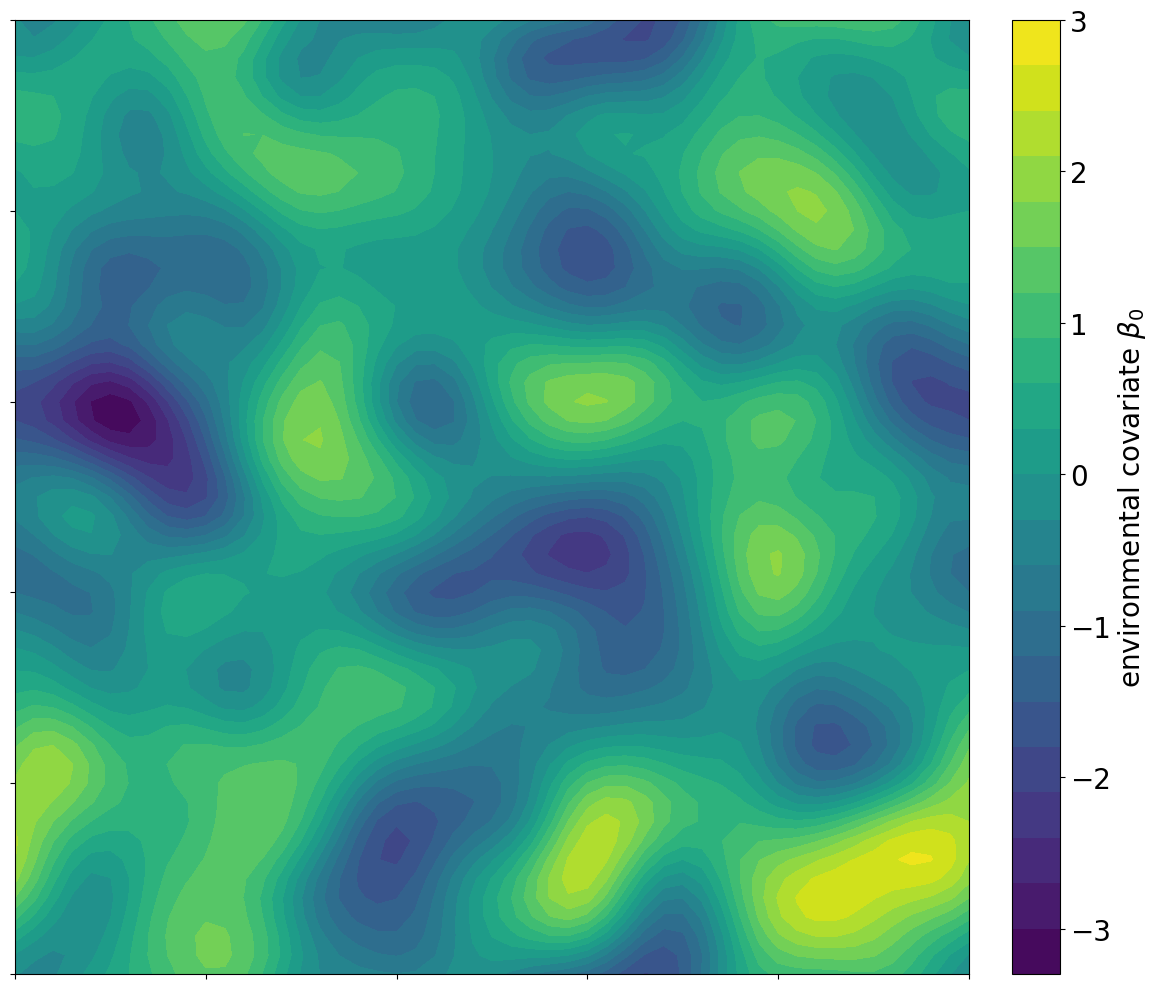

In [27]:
# Supplementary materials for environmental covariate
# figure B
#Axes.set_aspect('equal')
#fig,axs=plt.subplot()
#axs.set_aspect("equal")
# Figure A
# Setting aspect ratio 
fig, axs = plt.subplots(1, 1, figsize=(12,10),tight_layout=True)
axs.set_aspect('equal')
ax1=axs.contourf(cov1,cmap='viridis',levels=20)
#axs[0,0].set_title('A',loc='left',size=30,pad=100)
#axs.text(-0.15,1,'B', size=30, transform=axs.transAxes)
axs.tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax1, ax=axs,fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.set_label(label=r'environmental covariate $\beta_0$',size=20)
tick_locator = tick.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()

plt.savefig("Figure_2S.png",bbox_inches='tight',dpi=300)
plt.savefig("Figure_2s.pdf",bbox_inches='tight',dpi=300)
plt.show()

/tmp/ipykernel_236/3224492481.py:18: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar=plt.colorbar()


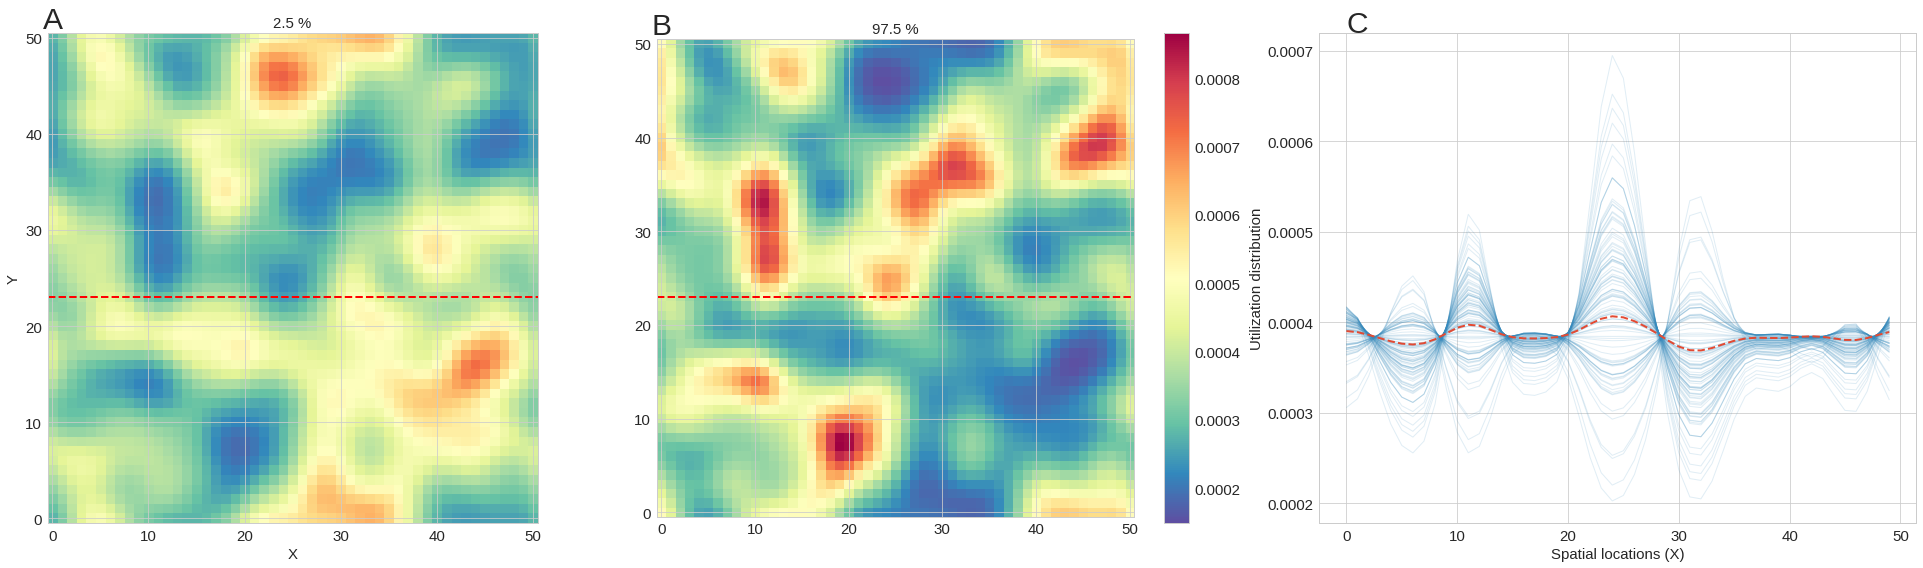

In [51]:
fig = plt.figure(figsize=(27, 8))

fig.add_subplot(1, 3, 1)
plt.imshow(UDL,origin="lower",vmin=UDU.min(),vmax=UDU.max(),cmap='Spectral_r')
plt.axhline(23,color="red",ls="--",linewidth=2)
plt.text(-1,51,'A', fontsize=30)
plt.title('2.5 %',fontsize=15)
plt.xlabel("X",fontsize=15)
plt.ylabel("Y",fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)

fig.add_subplot(1, 3, 2)
plt.imshow(UDU,origin="lower",vmin=UDU.min(),vmax=UDU.max(),cmap='Spectral_r')
plt.axhline(23,color="red",ls="--",linewidth=2)
plt.text(-1,51,'B', fontsize=30)
plt.title('97.5 %',fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)
cbar=plt.colorbar()
cbar.ax.tick_params(labelsize=15) 
cbar.update_ticks()
plt.tight_layout()

# Plotting log-likelihood of beta sampled randomly from the posterior distribution
ax = fig.add_subplot(1, 3, 3)
b1=d1[:,0,0] # Beta 1
b2=d1[:,0,1] #Beta 2
for i in range(S):
    UDS1=np.exp(b1[i]*cov1)
    UDS1=np.divide(UDS1,np.sum(UDS1))
    plt.plot(UDS1[23,0:50], color="C1",linewidth=1.0,alpha=0.15)
plt.plot(UDM[23,0:50],color="C0", linewidth=2,ls="--")
plt.xlabel("Spatial locations (X)",fontsize=15)
plt.ylabel("Utilization distribution",fontsize=15)
plt.text(0,0.00072,'C', fontsize=30)
plt.tick_params(axis='both', which='major', labelsize=15)


# Retain only unique labels
#handles, labels = plt.gca().get_legend_handles_labels()
#by_label = dict(zip(labels, handles))
#plt.legend(by_label.values(), by_label.keys(),loc="best",fontsize=14)

plt.tight_layout()

#plt.savefig('./Figures_4.png',dpi=300)
#plt.savefig('./Figures_4.pdf',dpi=300)

plt.show()

In [ ]:
# Setting plotting style
# plt.style.use('ggplot') 
# plt.style.use('seaborn-paper') 
# plt.style.use('seaborn-whitegrid')